# Demo: MIO Router **supervisado** — Actividad 3

Notebook listo para **Google Colab** (y para ejecutarlo localmente). Entrena modelos
de aprendizaje supervisado que predicen, para un par **origen → destino**:

- el **tiempo total** del viaje (regresión), y
- el **número de transbordos** (clasificación),

usando el motor simbólico original (Dijkstra sobre el grafo MIO) como **profesor**
que genera las etiquetas, y `scikit-learn` como conjunto de modelos.

| Componente | Papel |
|---|---|
| `supervised/dataset.py` | genera `datasets/od.csv` con Dijkstra como etiquetador |
| `supervised/features.py` | 18 features observables (geografía, corredor, zona, topología) |
| `supervised/train.py` | split por origen, modelos, métricas, guardado |
| `supervised/predict.py` | predice un viaje y lo contrasta con la ruta real |
| `mio_router/` | motor simbólico original (el "profesor") |


In [1]:
import os
import sys
import subprocess

# En Colab clona el repositorio; localmente ya estamos dentro del proyecto.
def ya_en_proyecto() -> bool:
    return os.path.isdir("supervised") and os.path.isdir("data")

if not ya_en_proyecto():
    REPO = "https://github.com/JersonMoreno21/Actividad-3-supervisado.git"
    if not os.path.isdir("Actividad-3-supervisado"):
        subprocess.run(["git", "clone", "-q", REPO], check=True)
    os.chdir("Actividad-3-supervisado")

sys.path.insert(0, os.getcwd())
print("Directorio de trabajo:", os.getcwd())

Directorio de trabajo: C:\Users\Usuario\Actividad 3 supervisada


In [2]:
# Única dependencia externa del proyecto (scikit-learn, pandas, numpy, matplotlib)
!pip install -q -r requirements.txt
print("dependencias listas")

dependencias listas


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from supervised.dataset import cargar_dataset, preparar, contar_transbordos
from supervised.features import FEATURES
from supervised.train import entrenar, cargar_modelos, separar, resumen
from supervised.predict import predecir

%matplotlib inline
print(f"{len(FEATURES)} features:", FEATURES)

18 features: ['lat_o', 'lon_o', 'lat_d', 'lon_d', 'dist_km', 'dlat', 'dlon', 'idx_corredor_o', 'idx_corredor_d', 'idx_zona_o', 'idx_zona_d', 'mismo_corredor', 'misma_zona', 'arista_directa', 'grado_o', 'grado_d', 'tipo_o', 'tipo_d']


## 1. Datos: pares origen→destino etiquetados por Dijkstra

Cada fila es un viaje entre dos nodos del sistema (81 estaciones + 9 nodos-zona = 90).
Las **etiquetas** (`tiempo`, `transbordos`) las calculó el motor simbólico.

In [4]:
import os

# Si el dataset no viene en el repo (o está desactualizado), se genera con Dijkstra
if not os.path.exists("datasets/od.csv"):
    from supervised.dataset import generar_dataset
    print("Generando datasets/od.csv con Dijkstra como profesor...")
    generar_dataset(verbose=True)

df = cargar_dataset("datasets/od.csv")
print(df.shape)
df.head()

(8010, 22)


,origen,destino,lat_o,lon_o,lat_d,lon_d,dist_km,dlat,dlon,idx_corredor_o,...,idx_zona_d,mismo_corredor,misma_zona,arista_directa,grado_o,grado_d,tipo_o,tipo_d,tiempo,transbordos
0,alamos,amanecer,3.484246,-76.513388,3.421568,-76.490780,7.407411,-0.062678,0.022608,1.0,...,0.0,0.0,0.0,0.0,2.0,3.0,0.0,0.0,41,4
1,alamos,atanasio_girardot,3.484246,-76.513388,3.444835,-76.508262,4.419100,-0.039411,0.005126,1.0,...,1.0,0.0,0.0,0.0,2.0,3.0,0.0,0.0,29,4
2,alamos,av_las_americas,3.484246,-76.513388,3.463389,-76.525423,2.676343,-0.020857,-0.012035,1.0,...,4.0,1.0,1.0,0.0,2.0,6.0,0.0,0.0,8,0
3,alamos,belalcazar,3.484246,-76.513388,3.444168,-76.520679,4.529350,-0.040078,-0.007291,1.0,...,1.0,0.0,0.0,0.0,2.0,5.0,0.0,0.0,25,4
4,alamos,brisas_de_mayo,3.484246,-76.513388,3.417576,-76.563839,9.290553,-0.066670,-0.050451,1.0,...,3.0,0.0,0.0,0.0,2.0,2.0,0.0,0.0,49,8


In [5]:
df[["tiempo", "transbordos", "dist_km"]].describe()

,tiempo,transbordos,dist_km
count,8010.000000,8010.000000,8010.000000
mean,29.017478,3.465668,4.868911
std,15.102205,2.087637,2.664961
min,1.000000,0.000000,0.085657
25%,18.000000,2.000000,2.967911
50%,29.000000,4.000000,4.539296
75%,39.000000,5.000000,6.365170
max,77.000000,10.000000,13.754279


## 2. Análisis exploratorio (EDA)

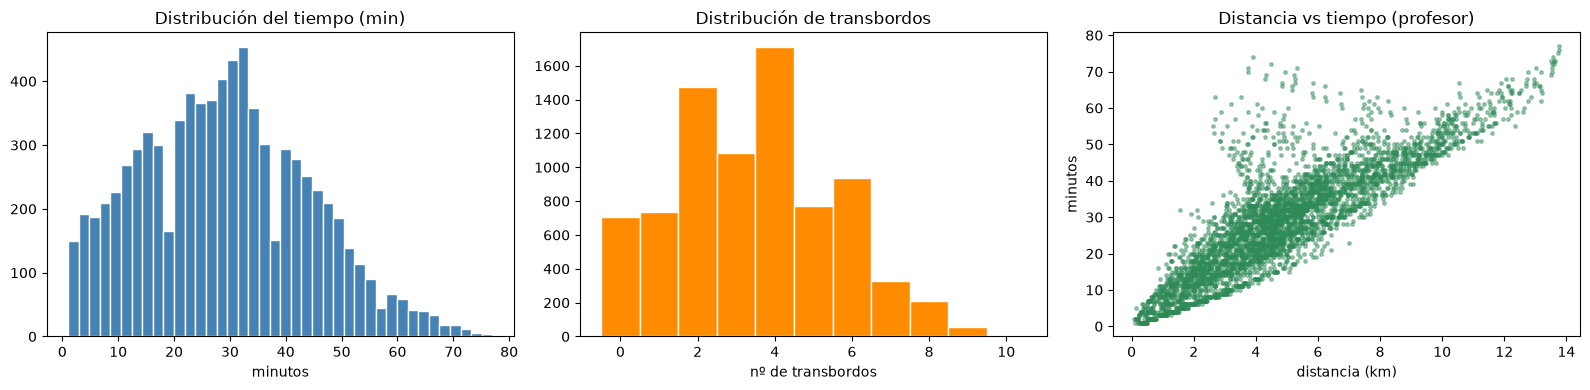

Correlación distancia-tiempo: 0.86


In [6]:
fig, ejes = plt.subplots(1, 3, figsize=(16, 4))

ejes[0].hist(df["tiempo"], bins=40, color="steelblue", edgecolor="white")
ejes[0].set_title("Distribución del tiempo (min)")
ejes[0].set_xlabel("minutos")

ejes[1].hist(df["transbordos"], bins=range(df["transbordos"].max() + 2),
             color="darkorange", edgecolor="white", align="left")
ejes[1].set_title("Distribución de transbordos")
ejes[1].set_xlabel("nº de transbordos")

ejes[2].scatter(df["dist_km"], df["tiempo"], s=6, alpha=0.25, color="seagreen")
ejes[2].set_title("Distancia vs tiempo (profesor)")
ejes[2].set_xlabel("distancia (km)")
ejes[2].set_ylabel("minutos")

plt.tight_layout()
plt.show()

print("Correlación distancia-tiempo:", round(df["dist_km"].corr(df["tiempo"]), 3))

## 3. Entrenamiento supervisado

Split **held-out por origen** (`seed=42`): los 90 orígenes se parten en grupo
de train (80 %) y grupo de test (20 %). Train = 5112 pares con ambos extremos
en el grupo de train; test = 1602 pares con origen en el grupo de test; se
descartan 1296 pares origen(train) → destino(test) porque su espejo tendría la
misma etiqueta. Así ningún par espejo (a,b)/(b,a) se cruza entre train y test.
El mejor modelo se elige con **GroupKFold (5 pliegues) sobre train**.

- **Tiempo (regresión):** Ridge, Random Forest, Gradient Boosting + 2 baselines.
- **Transbordos (clasificación):** Regresión Logística, KNN, Random Forest + baseline.

In [7]:
metrics = entrenar(df, guardar=True, verbose=True)
print()
print(resumen(metrics))

  [cv tiempo] baseline_media: {'mae': 12.629, 'mae_std': 0.936, 'r2': -0.0151}
  [cv tiempo] baseline_velocidad: {'mae': 5.883, 'mae_std': 0.462, 'r2': 0.7106}
  [cv tiempo] ridge: {'mae': 4.807, 'mae_std': 0.414, 'r2': 0.8176}


  [cv tiempo] random_forest: {'mae': 2.335, 'mae_std': 0.141, 'r2': 0.9368}


  [cv tiempo] gradient_boosting: {'mae': 3.2, 'mae_std': 0.211, 'r2': 0.9167}
  [cv transbordos] baseline_frecuente: {'accuracy': 0.195, 'accuracy_std': 0.0101, 'f1_macro': 0.0314}


  [cv transbordos] logreg: {'accuracy': 0.3921, 'accuracy_std': 0.0288, 'f1_macro': 0.3155}


  [cv transbordos] knn: {'accuracy': 0.6265, 'accuracy_std': 0.1029, 'f1_macro': 0.5652}


...

  [tiempo] random_forest: {'mae': 2.059, 'rmse': 2.76, 'r2': 0.9618}


  [tiempo] gradient_boosting: {'mae': 3.183, 'rmse': 4.046, 'r2': 0.918}
  [transbordos] baseline_frecuente: {'accuracy': 0.2503, 'f1_macro': 0.04, 'mae': 1.677}


  [transbordos] logreg: {'accuracy': 0.4513, 'f1_macro': 0.3438, 'mae': 1.059}
  [transbordos] knn: {'accuracy': 0.661, 'f1_macro': 0.6983, 'mae': 0.433}


  [transbordos] random_forest: {'accuracy': 0.7291, 'f1_macro': 0.7658, 'mae': 0.303}



Filas: 8010  (train 5112 / test 1602 / descartadas 1296)
Evaluación: held-out por origen  |  mejor modelo por: cv_train

TIEMPO (min) — sobre test
modelo                     MAE    RMSE        R²
baseline_media          11.669   14.37    -0.035
baseline_velocidad       5.683   7.897     0.687
ridge                     4.57   6.139     0.811
random_forest            2.059    2.76     0.962  <- mejor
gradient_boosting        3.183   4.046     0.918

TRANSBORDOS — sobre test
modelo                  accuracy  F1 macro     MAE
baseline_frecuente         0.250     0.040   1.677
logreg                     0.451     0.344   1.059
knn                        0.661     0.698   0.433
random_forest              0.729     0.766   0.303  <- mejor


In [8]:
filas = []
for tarea, m in (("tiempo", metrics["tiempo"]), ("transbordos", metrics["transbordos"])):
    for nombre, vals in m.items():
        filas.append({"tarea": tarea, "modelo": nombre, **vals})

tabla = pd.DataFrame(filas)
tabla

,tarea,modelo,mae,rmse,r2,accuracy,f1_macro
0,tiempo,baseline_media,11.669,14.370,-0.0353,NaN,NaN
1,tiempo,baseline_velocidad,5.683,7.897,0.6874,NaN,NaN
2,tiempo,ridge,4.570,6.139,0.8111,NaN,NaN
3,tiempo,random_forest,2.059,2.760,0.9618,NaN,NaN
4,tiempo,gradient_boosting,3.183,4.046,0.9180,NaN,NaN
5,transbordos,baseline_frecuente,1.677,NaN,NaN,0.2503,0.0400
6,transbordos,logreg,1.059,NaN,NaN,0.4513,0.3438
7,transbordos,knn,0.433,NaN,NaN,0.6610,0.6983
8,transbordos,random_forest,0.303,NaN,NaN,0.7291,0.7658


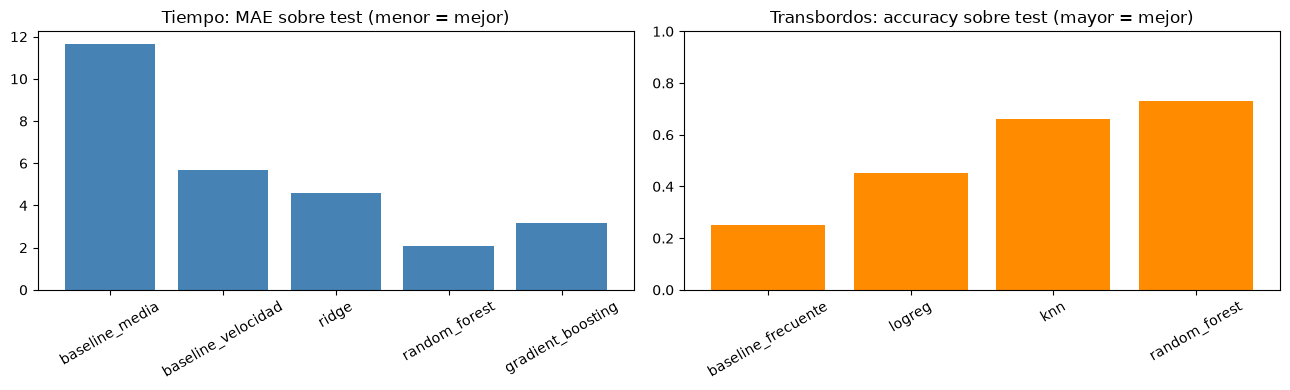

In [9]:
mejores_tiempo = metrics["tiempo"]
mejores_trans = metrics["transbordos"]

fig, ejes = plt.subplots(1, 2, figsize=(13, 4))
ejes[0].bar(mejores_tiempo.keys(), [v["mae"] for v in mejores_tiempo.values()],
            color="steelblue")
ejes[0].set_title("Tiempo: MAE sobre test (menor = mejor)")
ejes[0].tick_params(axis="x", rotation=30)

ejes[1].bar(mejores_trans.keys(), [v["accuracy"] for v in mejores_trans.values()],
            color="darkorange")
ejes[1].set_title("Transbordos: accuracy sobre test (mayor = mejor)")
ejes[1].tick_params(axis="x", rotation=30)
ejes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 4. ¿Qué tan bien predice el mejor modelo en todo el test set?

Comparamos la predicción de Random Forest contra las etiquetas **reales** de Dijkstra
sobre el test held-out (1602 pares cuyo origen nunca aparece en train).

In [10]:
bundle = cargar_modelos()
X_train, X_test, y_t_train, y_t_test, y_c_train, y_c_test = separar(df)

modelo_t = bundle["modelos_tiempo"][bundle["mejor_tiempo"]]
modelo_c = bundle["modelos_transbordos"][bundle["mejor_transbordos"]]

pred_t = modelo_t.predict(X_test)
pred_c = modelo_c.predict(X_test)

err_t = np.abs(pred_t - y_t_test)
err_c = np.abs(pred_c - y_c_test)

print(f"Mejor modelo de tiempo      : {bundle['mejor_tiempo']}")
print(f"  MAE {err_t.mean():.2f} min | mediana {np.median(err_t):.2f} min "
      f"| p90 {np.percentile(err_t, 90):.2f} min")
print(f"  predicciones exactas en ±2 min: {(err_t <= 2).mean():.1%}")
print(f"Mejor modelo de transbordos : {bundle['mejor_transbordos']}")
print(f"  exactitud {np.mean(pred_c == y_c_test):.1%} | MAE {err_c.mean():.3f}")

Mejor modelo de tiempo      : random_forest
  MAE 2.06 min | mediana 1.61 min | p90 4.52 min
  predicciones exactas en ±2 min: 59.6%
Mejor modelo de transbordos : random_forest
  exactitud 72.9% | MAE 0.303


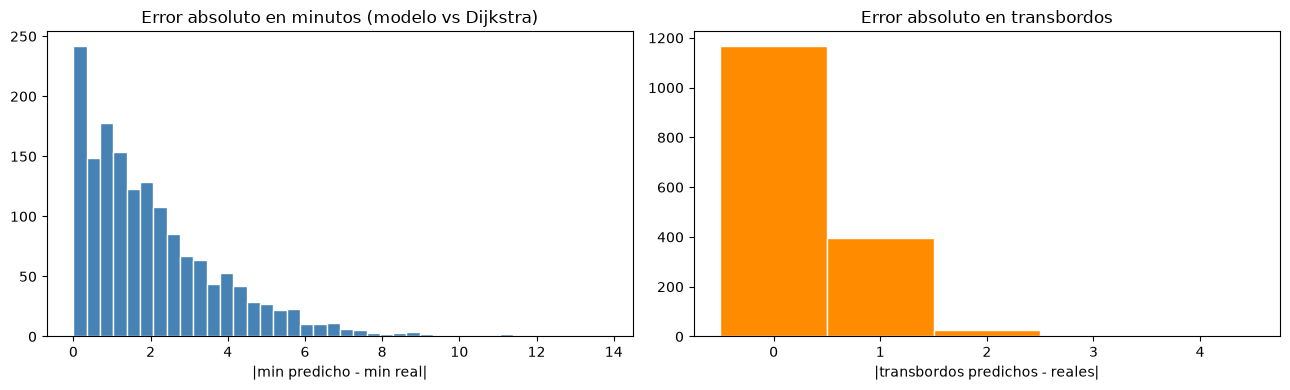

In [11]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 4))
ejes[0].hist(err_t, bins=40, color="steelblue", edgecolor="white")
ejes[0].set_title("Error absoluto en minutos (modelo vs Dijkstra)")
ejes[0].set_xlabel("|min predicho - min real|")
ejes[1].hist(err_c, bins=range(int(err_c.max()) + 2), color="darkorange",
             edgecolor="white", align="left")
ejes[1].set_title("Error absoluto en transbordos")
ejes[1].set_xlabel("|transbordos predichos - reales|")
plt.tight_layout()
plt.show()

## 5. Predicción de un viaje concreto

La función `predecir` devuelve la predicción **y** la ruta real del profesor para
poder compararlas.

In [12]:
res = predecir("Univalle", "Chiminangos")

print(f"Viaje: {res['origen']} -> {res['destino']}")
print(f"Predicción ({res['modelos']['tiempo']} / {res['modelos']['transbordos']}): "
      f"{res['tiempo_pred']} min, {res['transbordos_pred']} transbordos")
print(f"Real (Dijkstra)            : {res['tiempo_real']} min, "
      f"{res['transbordos_real']} transbordos")
print(f"Error                      : {res['error_tiempo']} min, "
      f"{res['error_transbordos']} transbordos")

pd.Series(res["por_modelo"]["tiempo"], name="minutos")

Viaje: univalle -> chiminangos
Predicción (random_forest / random_forest): 67 min, 8 transbordos
Real (Dijkstra)            : 67 min, 8 transbordos
Error                      : 0 min, 0 transbordos


baseline_media        29.888889
baseline_velocidad    74.659696
ridge                 65.148883
random_forest         66.700000
gradient_boosting     66.471233
Name: minutos, dtype: float64

In [13]:
# Se puede consultar también por nombre de zona (nodo virtual)
res = predecir("Paso del Comercio", "Universidades")
print(f"{res['origen']} -> {res['destino']}: "
      f"pred {res['tiempo_pred']} min vs real {res['tiempo_real']} min")

zona_paso_del_comercio -> universidades: pred 67 min vs real 68 min


## 6. La CLI de la versión supervisada

Mismos comandos que en un terminal:

In [14]:
def cmd(*args):
    r = subprocess.run([sys.executable, "-m", "supervised", *args],
                       capture_output=True, text=True, encoding="utf-8",
                       errors="replace")
    print(r.stdout, end="")
    if r.stderr:
        print(r.stderr, end="")
    return r

cmd("--help")
cmd("evaluar")
cmd("predecir", "--origen", "Univalle", "--destino", "Chiminangos", "--todos")

usage: python -m supervised [-h]
                            {generar,entrenar,predecir,evaluar,listar} ...

Versión supervisada (ML) del ruteo del MIO de Cali.

positional arguments:
  {generar,entrenar,predecir,evaluar,listar}
    generar             Genera datasets/od.csv con Dijkstra como profesor
    entrenar            Entrena los modelos supervisados
    predecir            Predice un viaje origen-destino
    evaluar             Muestra las métricas del último entrenamiento
    listar              Lista las estaciones (pares OD)

options:
  -h, --help            show this help message and exit


Filas: 8010  (train 5112 / test 1602 / descartadas 1296)
Evaluación: held-out por origen  |  mejor modelo por: cv_train

TIEMPO (min) — sobre test
modelo                     MAE    RMSE        R²
baseline_media          11.669   14.37    -0.035
baseline_velocidad       5.683   7.897     0.687
ridge                     4.57   6.139     0.811
random_forest            2.059    2.76     0.962  <- mejor
gradient_boosting        3.183   4.046     0.918

TRANSBORDOS — sobre test
modelo                  accuracy  F1 macro     MAE
baseline_frecuente         0.250     0.040   1.677
logreg                     0.451     0.344   1.059
knn                        0.661     0.698   0.433
random_forest              0.729     0.766   0.303  <- mejor


[OK] Viaje: univalle -> chiminangos
Predicción (modelo random_forest): 67 min, 8 transbordos
Real (Dijkstra)  : 67 min, 8 transbordos
Error            : 0 min, 0 transbordos

Por modelo:
  tiempo       baseline_media            29.9 min
  tiempo       baseline_velocidad        74.7 min
  tiempo       gradient_boosting         66.5 min
  tiempo       random_forest             66.7 min
  tiempo       ridge                     65.1 min
  transbordos  baseline_frecuente           4
  transbordos  knn                          7
  transbordos  logreg                       6
  transbordos  random_forest                8


CompletedProcess(args=['C:\\Users\\Usuario\\AppData\\Local\\Python\\pythoncore-3.14-64\\python.exe', '-m', 'supervised', 'predecir', '--origen', 'Univalle', '--destino', 'Chiminangos', '--todos'], returncode=0, stdout='[OK] Viaje: univalle -> chiminangos\nPredicción (modelo random_forest): 67 min, 8 transbordos\nReal (Dijkstra)  : 67 min, 8 transbordos\nError            : 0 min, 0 transbordos\n\nPor modelo:\n  tiempo       baseline_media            29.9 min\n  tiempo       baseline_velocidad        74.7 min\n  tiempo       gradient_boosting         66.5 min\n  tiempo       random_forest             66.7 min\n  tiempo       ridge                     65.1 min\n  transbordos  baseline_frecuente           4\n  transbordos  knn                          7\n  transbordos  logreg                       6\n  transbordos  random_forest                8\n', stderr='')

## 7. Pruebas (pytest)

71 tests del motor simbólico original + 45 tests del pipeline supervisado.

In [15]:
r = subprocess.run([sys.executable, "-m", "pytest", "tests/", "-q"],
                   capture_output=True, text=True, encoding="utf-8",
                   errors="replace")
print(r.stdout[-1500:])
print(r.stderr[-500:] if r.returncode else "")

........................................................................ [ 62%]
............................................                             [100%]
116 passed in 106.77s (0:01:46)




## 8. Conclusiones

- El **profesor** (Dijkstra sobre el grafo MIO) etiqueta 8010 pares origen→destino.
- Con 18 features observables, **Random Forest** predice el tiempo con
  **MAE ≈ 2,1 min** (R² ≈ 0,96) y el número de transbordos con
  **accuracy ≈ 0,73**, muy por encima de los baselines (media: MAE ≈ 11,7 min;
  clase más frecuente: accuracy ≈ 0,25) en un test que **no** comparte
  pares espejo ni orígenes con train.
- La ventaja sobre los baselines confirma que las features (geografía + corredor +
  zona + topología) sí contienen señal del sistema de rutas.
- **Límite:** el modelo *aproxima* al profesor; para una ruta garantizada óptima
  sigue usándose Dijkstra (`mio_router`). El modelo sirve para estimar viajes de
  forma instantánea y para mostrar un flujo completo de aprendizaje supervisado.